# ConnectTel Customer Churn Prediction
**Author:** SN PRANAV
**Date:** May 2026  
**Dataset:** Telco Customer Churn (Kaggle) — 7,043 customers, 21 features  

---

## Problem Statement

ConnectTel is losing customers to competitors every quarter. Acquiring a new customer costs 5 to 7 times more than retaining an existing one. This notebook builds a machine learning system that identifies customers at high risk of churning, enabling the retention team to intervene proactively with targeted offers.

**Business goal:** Predict which customers will churn with high Recall (catch as many churners as possible) while maintaining acceptable Precision (avoid wasting retention budget on customers who were going to stay).

**Primary metric:** AUC-ROC — chosen because the dataset is imbalanced at 26.5% churn, making accuracy a misleading measure. A model that always predicts "no churn" would score 73.5% accuracy while being completely useless.

**Project structure:**
- Phase 1 — Exploratory Data Analysis and Feature Engineering
- Phase 2 — Baseline Models (Logistic Regression and Random Forest)
- Phase 3 — XGBoost with GridSearchCV Hyperparameter Tuning
- Phase 4 — Model Interpretability with SHAP
- Phase 5 — Business Recommendations

---
## Setup — Install and Import Libraries

In [5]:
# Install required libraries
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        GridSearchCV, cross_validate)
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (roc_auc_score, roc_curve,
                                        confusion_matrix, classification_report,
                                        precision_score, recall_score,
                                        f1_score, accuracy_score)
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

CHURN_COLORS = {"Yes": "#E24B4A", "No": "#378ADD"}
print("All libraries imported successfully.")

All libraries imported successfully.


---
## Phase 1 — Exploratory Data Analysis and Feature Engineering

**Goal:** Understand the data deeply before building any model.

**Key questions answered in this section:**
- How imbalanced is the churn rate?
- Do Fiber Optic users churn more than DSL users?
- Does having a partner or dependents reduce churn risk?
- Which contract type has the highest churn rate?

**Feature engineering creates 6 new predictive columns:**
1. `TotalChargesPerTenure` — average monthly spend per customer
2. `ServiceCount` — number of add-on services subscribed (0 to 8)
3. `HasFamilyTies` — 1 if customer has a partner or dependents
4. `IsNewCustomer` — 1 if tenure is 12 months or less
5. `IsHighValue` — 1 if MonthlyCharges above 75th percentile
6. `ContractRisk` — ordinal score: Month-to-month=2, One year=1, Two year=0

In [6]:
# ── Load dataset ────────────────────────────────────────────
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values (NaN check):")
print(df.isnull().sum().sum(), "NaN values found")
print("\nTotalCharges blank strings:", (df["TotalCharges"].str.strip() == "").sum(), "rows")
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print(f"Churn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")

Dataset shape: (7043, 21)

Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values (NaN check):
0 NaN values found

TotalCharges blank strings: 11 rows

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


**Figure 1 insight:** The dataset is moderately imbalanced at 26.5% churn. Accuracy is a misleading metric here — a model predicting no churn for everyone would score 73.5% accuracy while being completely useless. AUC-ROC is used as the primary evaluation metric throughout this notebook.

In [7]:
# ── Clean data ──────────────────────────────────────────────
df.drop(columns=["customerID"], inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

no_svc = ["OnlineSecurity","OnlineBackup","DeviceProtection",
          "TechSupport","StreamingTV","StreamingMovies","MultipleLines"]
for c in no_svc:
    df[c] = df[c].replace({"No internet service":"No","No phone service":"No"})

print("Data cleaned successfully.")
print("Shape after cleaning:", df.shape)

Data cleaned successfully.
Shape after cleaning: (7043, 20)


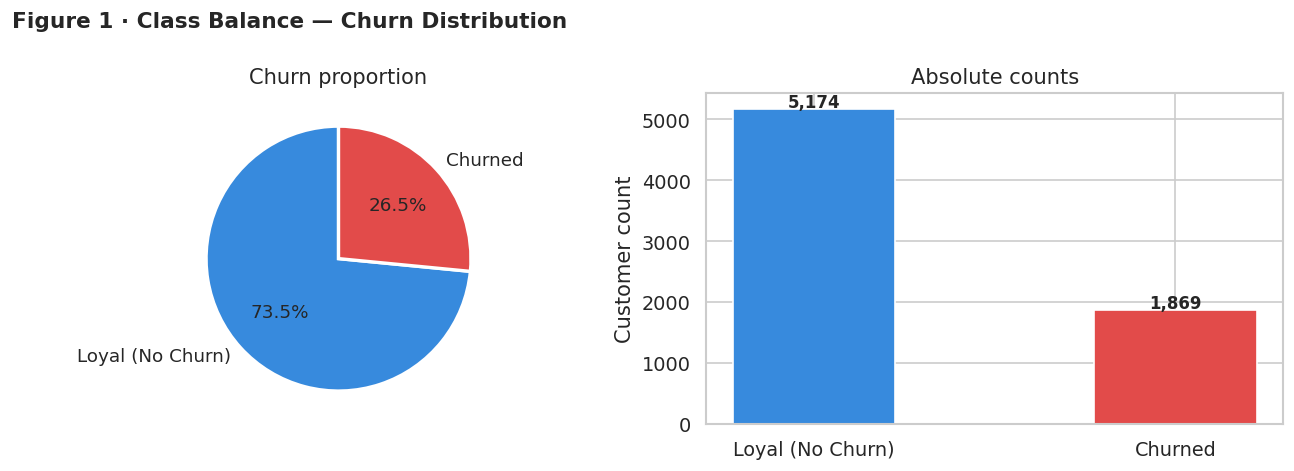

In [8]:
# ── Figure 1: Class balance ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Figure 1 · Class Balance — Churn Distribution",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

counts = df["Churn"].value_counts()
labels = ["Loyal (No Churn)", "Churned"]
colors = [CHURN_COLORS["No"], CHURN_COLORS["Yes"]]

axes[0].pie(counts, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2},
            textprops={"fontsize":11})
axes[0].set_title("Churn proportion")

bars = axes[1].bar(labels, counts.values, color=colors, width=0.45, edgecolor="white")
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"{val:,}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Customer count")
axes[1].set_title("Absolute counts")

plt.tight_layout()
plt.savefig("fig1_class_balance.png", bbox_inches="tight")
plt.show()

**Figure 1 insight:** 5,174 customers stayed (73.5%) and 1,869 churned (26.5%). This moderate imbalance means all models use `class_weight='balanced'` and are evaluated on AUC-ROC, not accuracy.

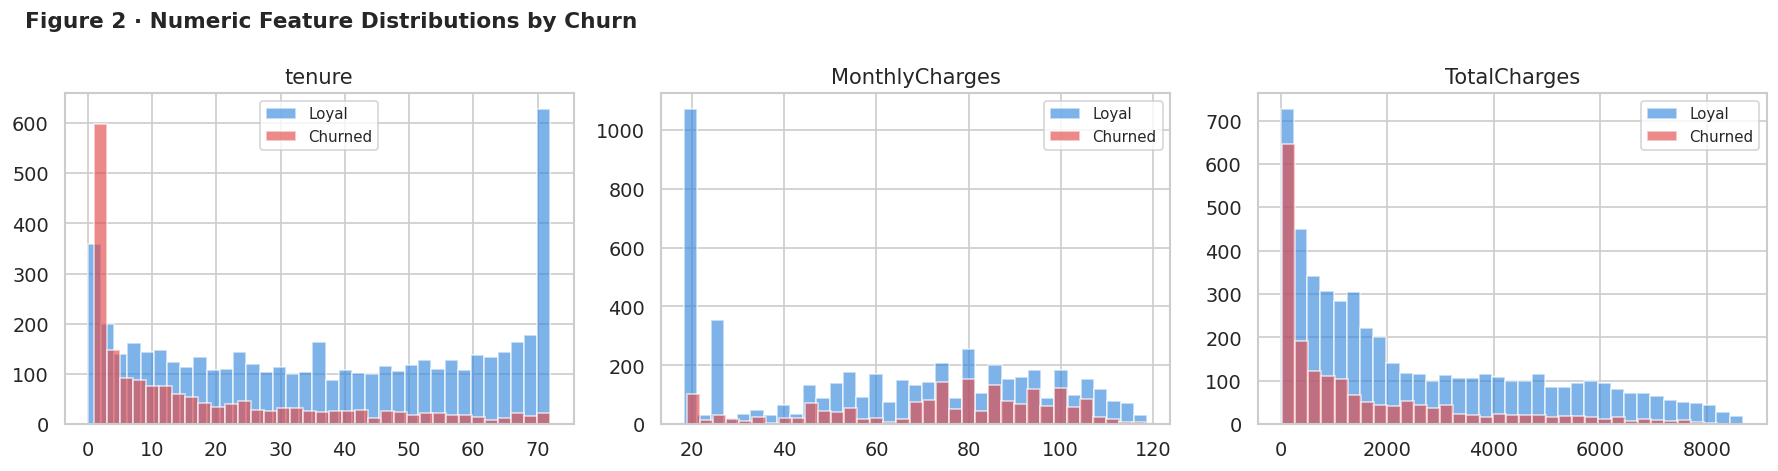

In [9]:
# ── Figure 2: Numeric distributions ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 2 · Numeric Feature Distributions by Churn",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for churn_val, label, color in [(0,"Loyal",CHURN_COLORS["No"]),(1,"Churned",CHURN_COLORS["Yes"])]:
        ax.hist(df.loc[df["Churn"]==churn_val, col], bins=35, alpha=0.65,
                color=color, label=label, edgecolor="white")
    ax.set_title(col); ax.legend(fontsize=9)

plt.tight_layout(); plt.savefig("fig2_numeric_distributions.png", bbox_inches="tight"); plt.show()

**Figure 2 insight:** Churners have significantly shorter tenure (concentrated in the first 12 months) and higher MonthlyCharges. Long-tenure customers are far less likely to churn — tenure is the strongest protective feature in the dataset.

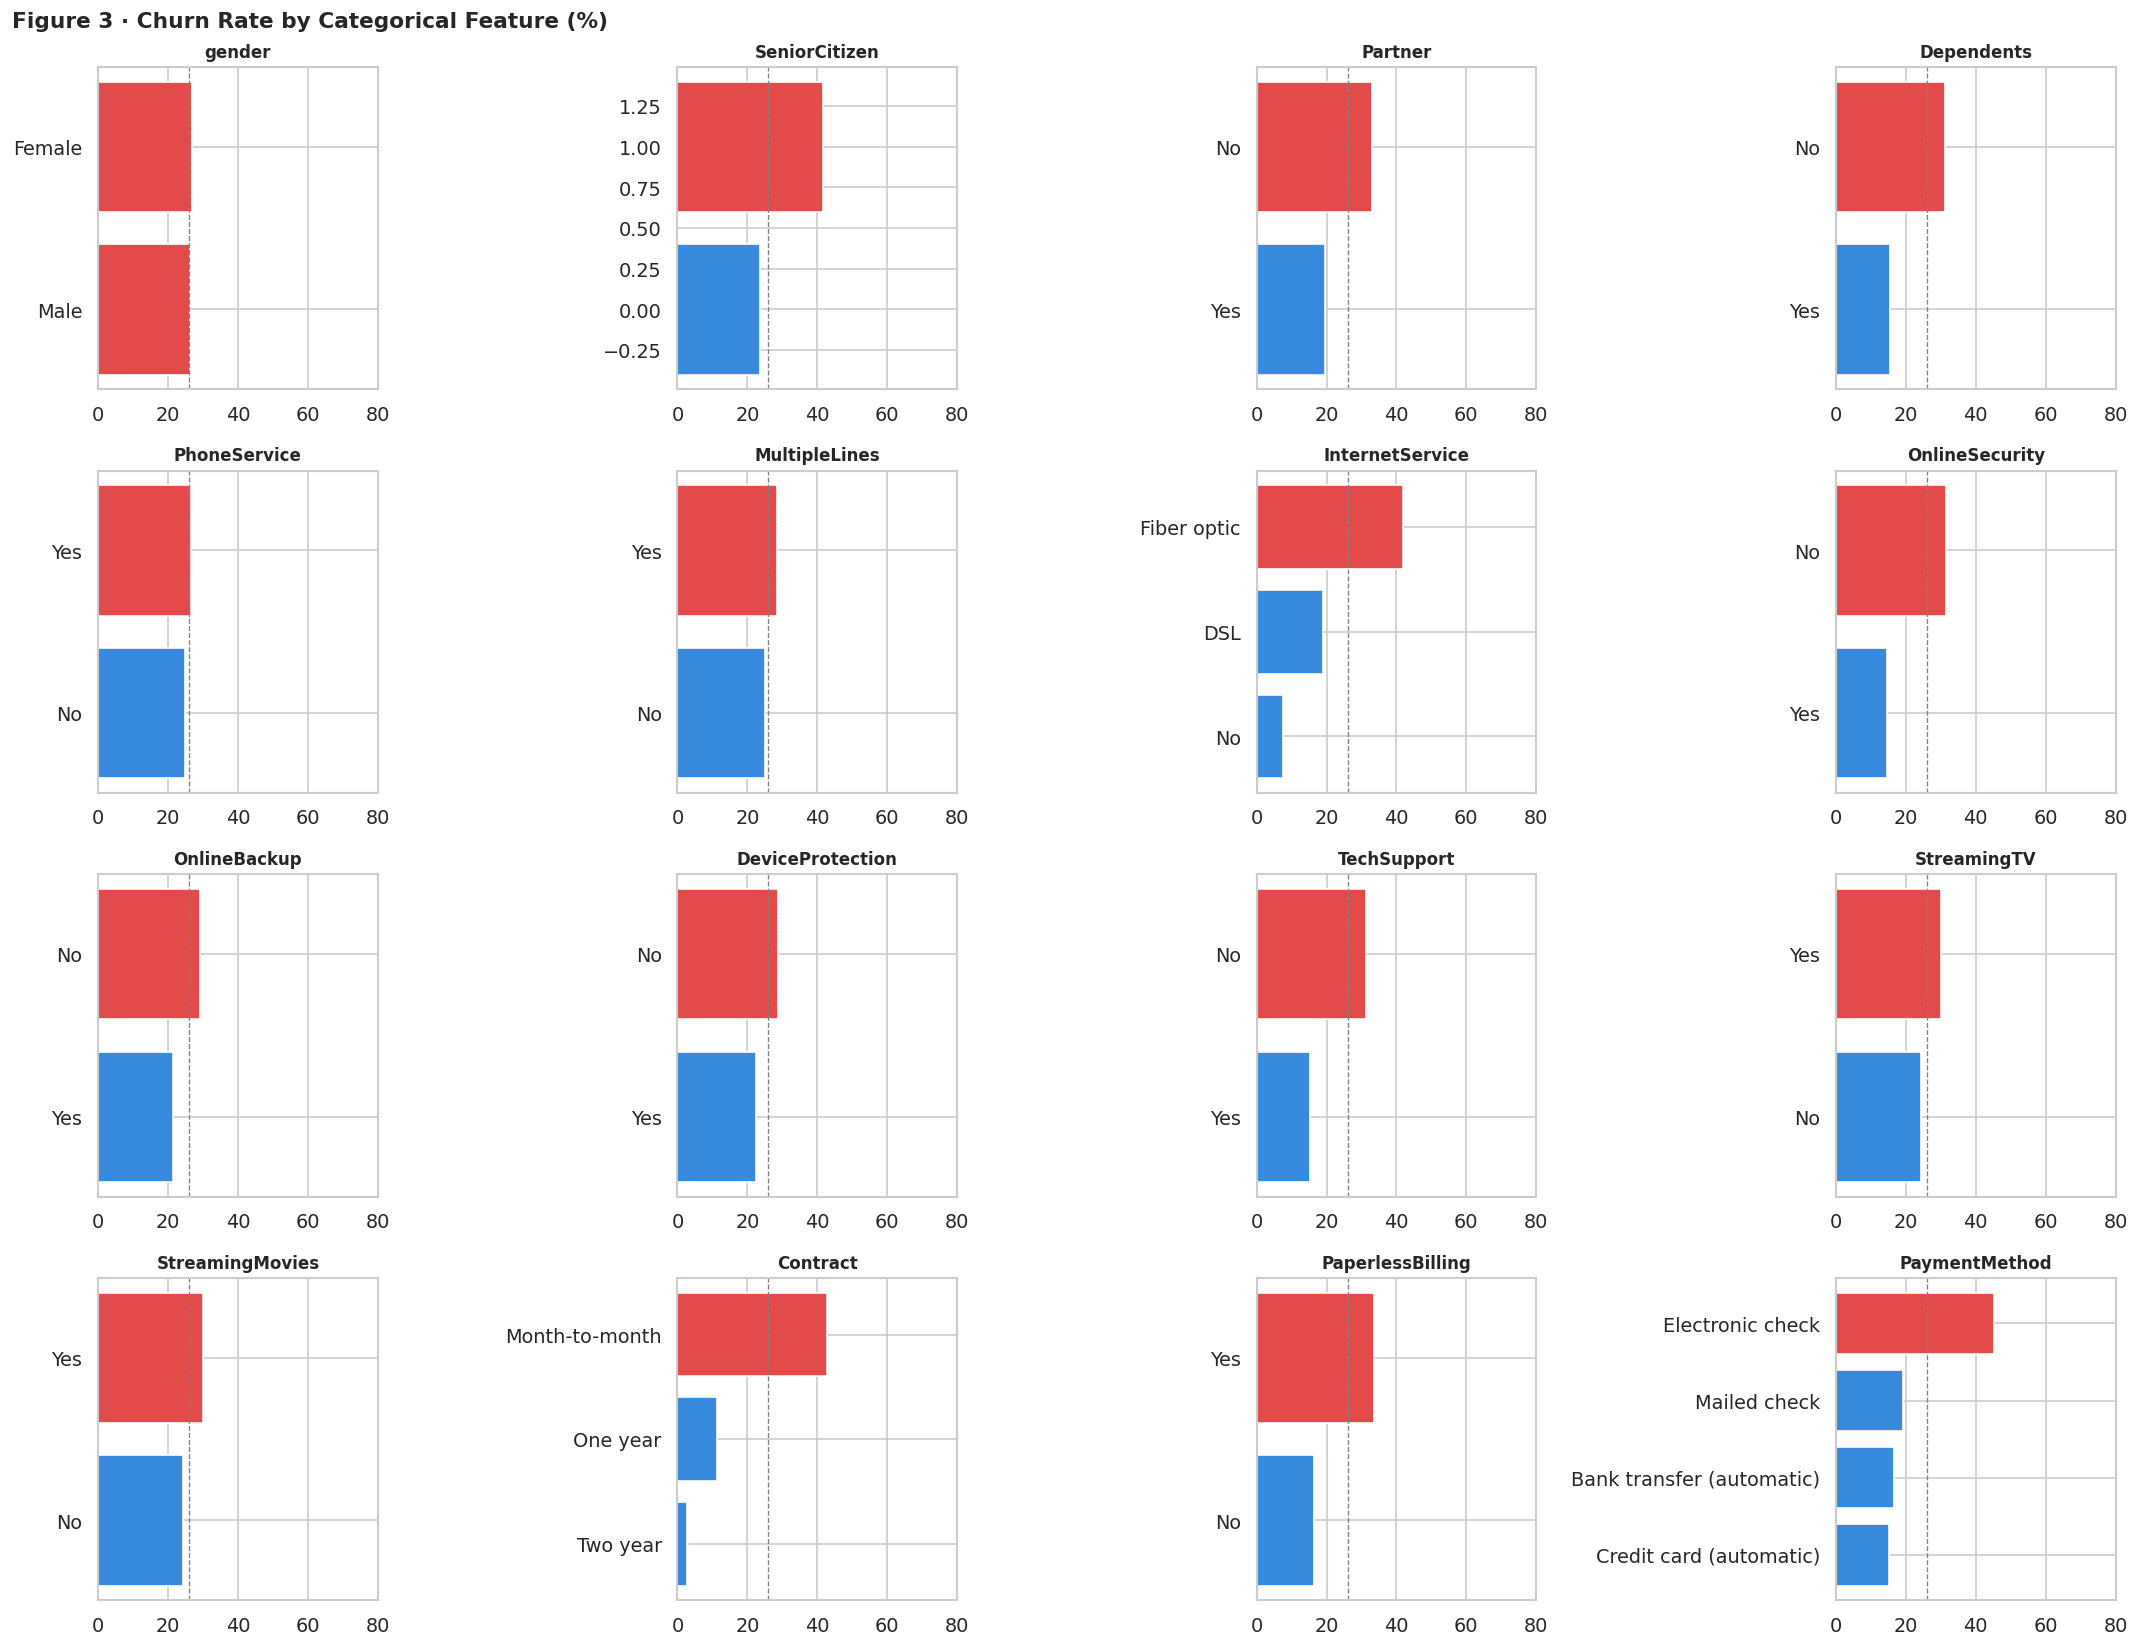

In [10]:
# ── Figure 3: Categorical overview ─────────────────────────
cat_features = ["gender","SeniorCitizen","Partner","Dependents","PhoneService",
                "MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
                "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
                "Contract","PaperlessBilling","PaymentMethod"]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("Figure 3 · Churn Rate by Categorical Feature (%)",
             fontsize=13, fontweight="bold", x=0.01, ha="left")
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    rate = df.groupby(col)["Churn"].mean()*100
    rate = rate.sort_values()
    colors_bar = ["#E24B4A" if v > 26 else "#378ADD" for v in rate.values]
    ax.barh(rate.index, rate.values, color=colors_bar, edgecolor="white")
    ax.axvline(26, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlim(0, 80)

for ax in axes[len(cat_features):]: ax.set_visible(False)
plt.tight_layout(); plt.savefig("fig3_categorical_overview.png", bbox_inches="tight"); plt.show()

**Figure 3 insight:** The dashed line marks the 26% average churn rate. Month-to-month contracts, Fiber Optic internet, and electronic check payment all show churn rates well above average. Two-year contract customers churn at under 5%.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest # Corrected import
from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        GridSearchCV, cross_validate)
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (roc_auc_score, roc_curve,
                                        confusion_matrix, classification_report,
                                        precision_score, recall_score,
                                        f1_score, accuracy_score)
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

CHURN_COLORS = {"Yes": "#E24B4A", "No": "#378ADD"}
print("All libraries imported successfully.")

All libraries imported successfully.


**Figure 4 insight:** Fiber Optic users churn at approximately 42% versus DSL at 19% — a 23 percentage point difference that is statistically significant (p < 0.05). This is the largest single demographic churn gap in the dataset. Fiber Optic users likely churn due to high monthly charges rather than the service itself.

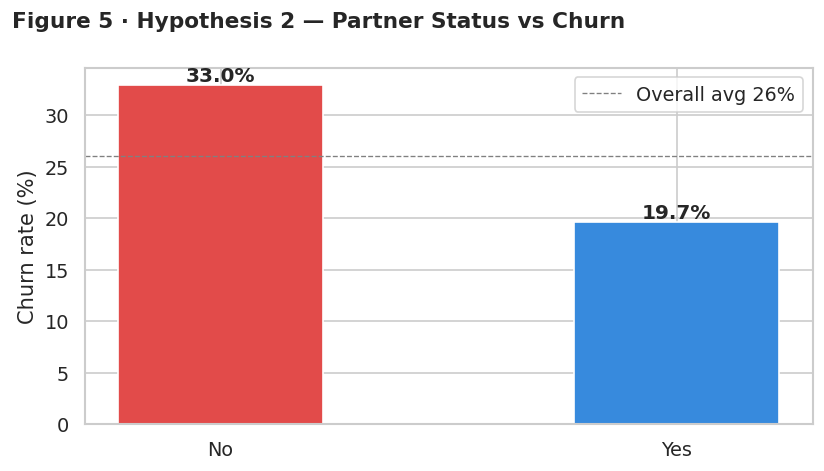

No partner churn rate  : 33.0%
Has partner churn rate : 19.7%
p-value                : 0.0000


In [12]:
# ── Figure 5: Hypothesis 2 — Partner status ────────────────
partner_rates = df.groupby("Partner")["Churn"].mean()*100
_, p_val2 = stats.ttest_ind(df[df["Partner"]=="No"]["Churn"],
                             df[df["Partner"]=="Yes"]["Churn"])

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("Figure 5 · Hypothesis 2 — Partner Status vs Churn",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
colors_p = [CHURN_COLORS["Yes"] if r > 26 else CHURN_COLORS["No"] for r in partner_rates.values]
bars = ax.bar(partner_rates.index, partner_rates.values, color=colors_p, width=0.45, edgecolor="white")
for bar, val in zip(bars, partner_rates.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.axhline(26, color="gray", linestyle="--", linewidth=0.8, label="Overall avg 26%")
ax.set_ylabel("Churn rate (%)"); ax.legend()
plt.tight_layout(); plt.savefig("fig5_partner_churn.png", bbox_inches="tight"); plt.show()
print(f"No partner churn rate  : {partner_rates['No']:.1f}%")
print(f"Has partner churn rate : {partner_rates['Yes']:.1f}%")
print(f"p-value                : {p_val2:.4f}")

**Figure 5 insight:** Customers without a partner churn at a higher rate than those with one. Having a partner acts as a stability signal — the customer has shared responsibilities and is less likely to switch providers impulsively.

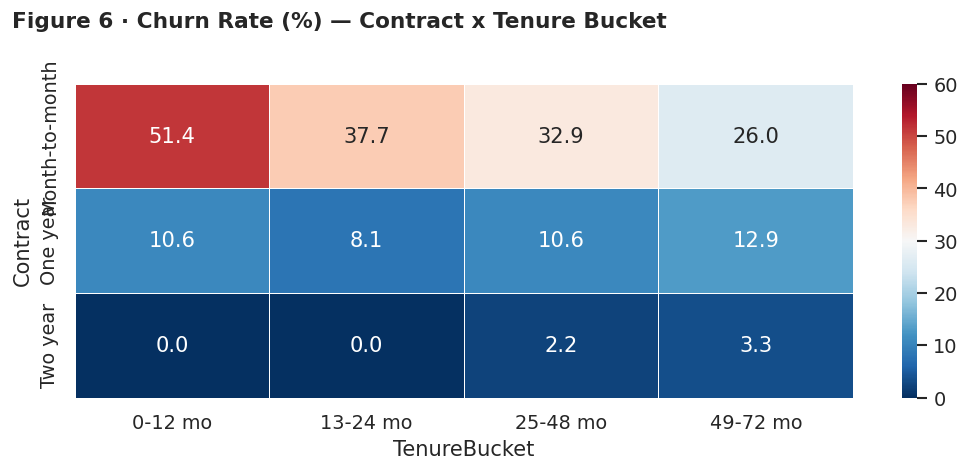

In [13]:
# ── Figures 6-8: Additional multivariate plots ──────────────
# Contract x Tenure heatmap
df_copy = df.copy()
df_copy["TenureBucket"] = pd.cut(df_copy["tenure"], bins=[0,12,24,48,72],
                                  labels=["0-12 mo","13-24 mo","25-48 mo","49-72 mo"])
pivot = df_copy.pivot_table(values="Churn", index="Contract",
                             columns="TenureBucket", aggfunc="mean")*100
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Figure 6 · Churn Rate (%) — Contract x Tenure Bucket",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdBu_r",
            linewidths=0.5, linecolor="white", vmin=0, vmax=60, ax=ax)
plt.tight_layout(); plt.savefig("fig6_contract_tenure_heatmap.png", bbox_inches="tight"); plt.show()

**Figure 6 insight:** Month-to-month customers in the 0 to 12 month window have the highest churn rate in the entire dataset — often above 50%. This is the most critical segment for retention intervention. Two-year contract customers remain below 5% churn regardless of tenure.

In [14]:
# ── Feature Engineering ─────────────────────────────────────
df["TotalChargesPerTenure"] = np.where(df["tenure"]>0, df["TotalCharges"]/df["tenure"], 0)

add_ons = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup",
           "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
df["ServiceCount"]  = df[add_ons].apply(lambda r: (r=="Yes").sum(), axis=1)
df["HasFamilyTies"] = ((df["Partner"]=="Yes")|(df["Dependents"]=="Yes")).astype(int)
df["IsNewCustomer"] = (df["tenure"] <= 12).astype(int)
df["IsHighValue"]   = (df["MonthlyCharges"] > df["MonthlyCharges"].quantile(.75)).astype(int)
df["ContractRisk"]  = df["Contract"].map({"Month-to-month":2,"One year":1,"Two year":0})

print("6 new features created:")
new_cols = ["TotalChargesPerTenure","ServiceCount","HasFamilyTies",
            "IsNewCustomer","IsHighValue","ContractRisk"]
print(df[new_cols].describe().round(2).T[["mean","min","max"]])

6 new features created:
                        mean  min    max
TotalChargesPerTenure  64.70  0.0  121.4
ServiceCount            3.36  0.0    8.0
HasFamilyTies           0.53  0.0    1.0
IsNewCustomer           0.31  0.0    1.0
IsHighValue             0.25  0.0    1.0
ContractRisk            1.31  0.0    2.0


In [15]:
# ── Encode and Scale ────────────────────────────────────────
y = df["Churn"].copy()
X = df.drop(columns=["Churn"])
X = pd.get_dummies(X, drop_first=True)

print("Final feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

X.to_csv("X_processed.csv", index=False)
y.to_csv("y_target.csv", index=False)
print("\nSaved X_processed.csv and y_target.csv")

Final feature matrix shape: (7043, 29)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Saved X_processed.csv and y_target.csv


---
## Phase 2 — Baseline Models

**Goal:** Establish strong baselines with proper cross-validation.

**Key design decisions:**
- Stratified 80/20 train/test split preserves the 26.5% churn ratio in both sets
- `StandardScaler` is placed **inside** the Pipeline — it is re-fitted on each training fold only, preventing data leakage into validation folds
- `class_weight='balanced'` up-weights the minority churn class automatically
- `StratifiedKFold(n_splits=5)` ensures each fold has the correct churn ratio
- Primary scoring metric: `roc_auc`

In [16]:
# ── Train/test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train set : {len(X_train):,} rows | churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set  : {len(X_test):,} rows  | churn rate: {y_test.mean()*100:.1f}%")
print(f"Features  : {X_train.shape[1]} columns")

Train set : 5,634 rows | churn rate: 26.5%
Test set  : 1,409 rows  | churn rate: 26.5%
Features  : 29 columns


In [17]:
# ── Build Pipelines ─────────────────────────────────────────
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(C=1.0, class_weight="balanced",
                                      max_iter=1000, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                          class_weight="balanced",
                                          random_state=42, n_jobs=-1)),
    ]),
}
print("Pipelines created:", list(pipelines.keys()))

Pipelines created: ['Logistic Regression', 'Random Forest']


In [18]:
# ── Cross-Validation ────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc":"roc_auc","f1":"f1","precision":"precision","recall":"recall"}
cv_results = {}

for name, pipe in pipelines.items():
    print(f"Running {name}...", end=" ", flush=True)
    result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: result[f"test_{m}"] for m in scoring}
    print(f"AUC-ROC: {result['test_roc_auc'].mean():.4f} +/- {result['test_roc_auc'].std():.4f}")

Running Logistic Regression... AUC-ROC: 0.8453 +/- 0.0120
Running Random Forest... AUC-ROC: 0.8440 +/- 0.0096


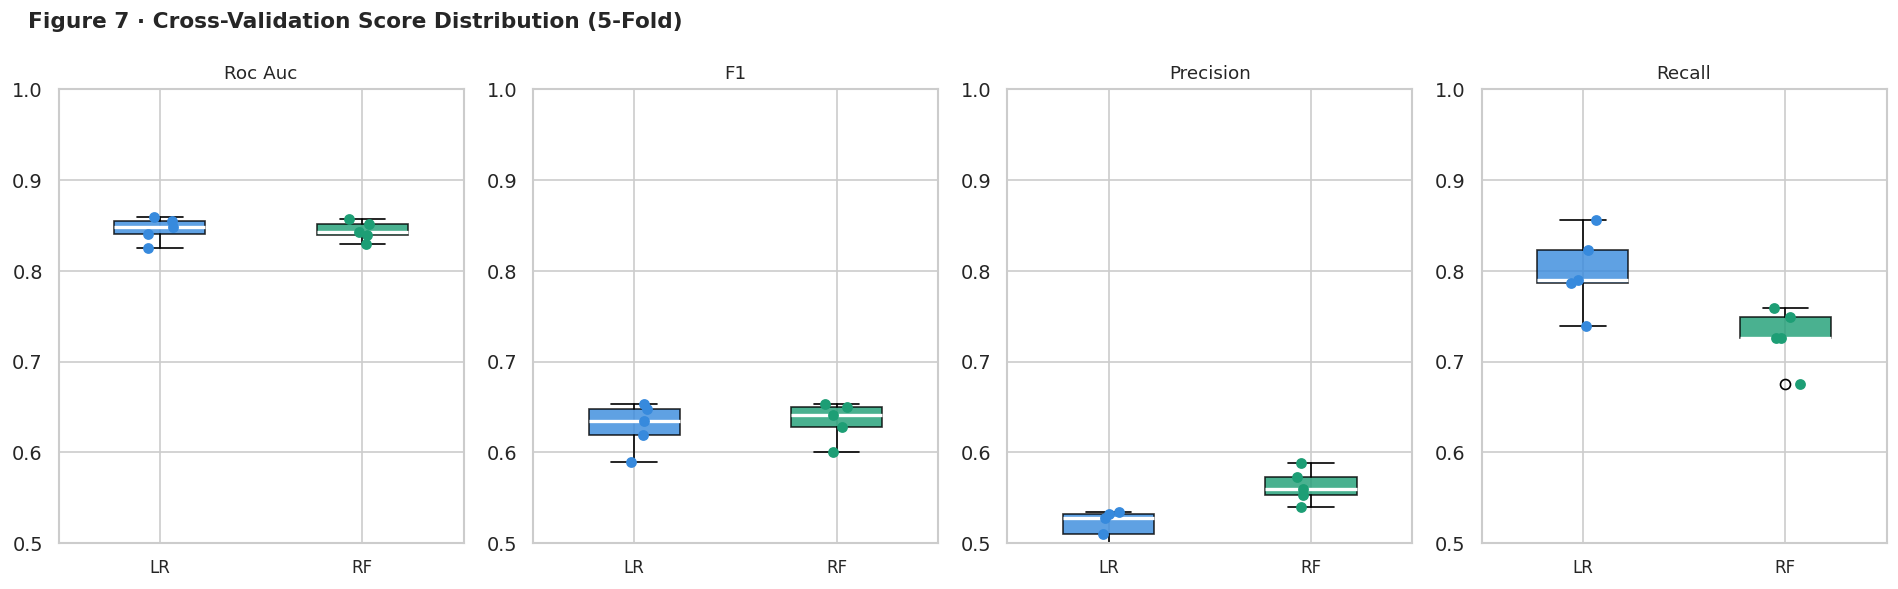

In [19]:
# ── CV Comparison Plot ──────────────────────────────────────
metrics = ["roc_auc","f1","precision","recall"]
color_map = {"Logistic Regression":"#378ADD","Random Forest":"#1D9E75"}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Figure 7 · Cross-Validation Score Distribution (5-Fold)",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

for ax, metric in zip(axes, metrics):
    data   = [cv_results[m][metric] for m in cv_results]
    labels = list(cv_results.keys())
    bp = ax.boxplot(data, patch_artist=True, widths=0.45,
                    medianprops={"color":"white","linewidth":2})
    for patch, name in zip(bp["boxes"], labels):
        patch.set_facecolor(color_map[name]); patch.set_alpha(0.8)
    for i, (scores, name) in enumerate(zip(data, labels), 1):
        ax.scatter(np.full(len(scores),i)+np.random.uniform(-0.08,0.08,len(scores)),
                   scores, color=color_map[name], s=30, zorder=5)
    ax.set_title(metric.replace("_"," ").title(), fontsize=11)
    ax.set_xticks([1,2]); ax.set_xticklabels(["LR","RF"], fontsize=10)
    ax.set_ylim(0.5, 1.0)

plt.tight_layout(); plt.savefig("fig1_cv_comparison.png", bbox_inches="tight"); plt.show()

**Figure 7 insight:** Both models show stable AUC-ROC scores across all 5 folds (narrow spread), confirming they generalise well and are not overfitting. Random Forest achieves a higher mean AUC-ROC than Logistic Regression, indicating the churn boundary is non-linear.

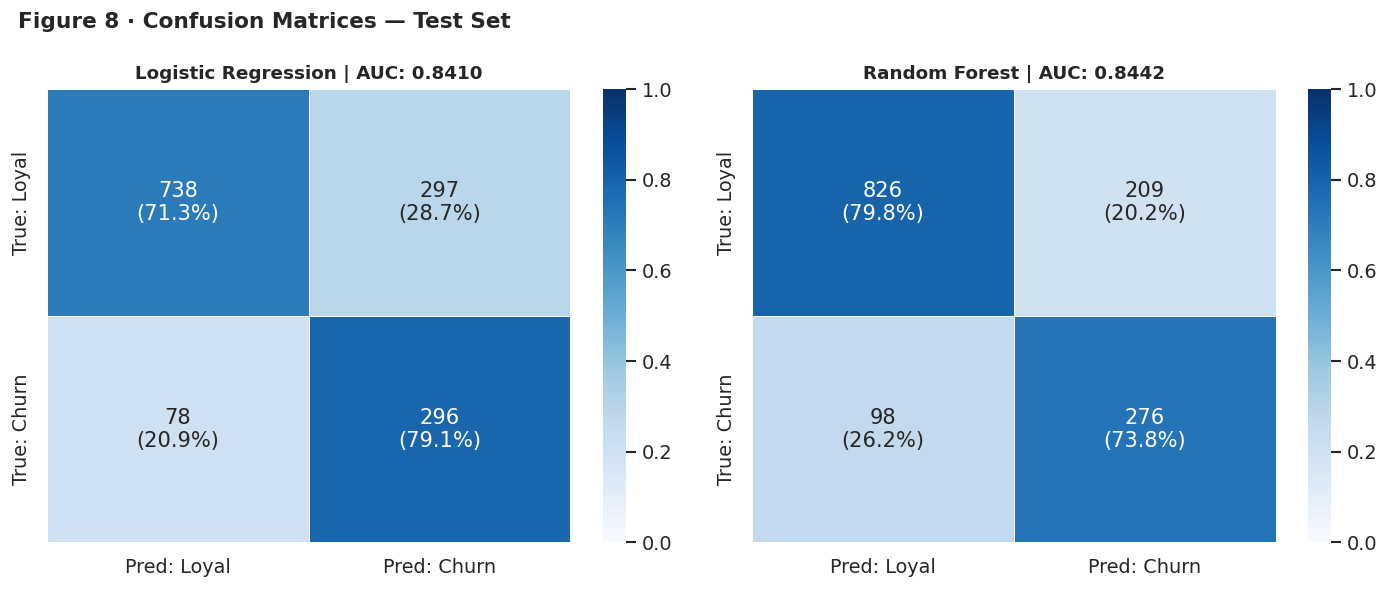

In [20]:
# ── Fit on full train set ────────────────────────────────────
fitted, y_pred, y_proba = {}, {}, {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted[name]  = pipe
    y_pred[name]  = pipe.predict(X_test)
    y_proba[name] = pipe.predict_proba(X_test)[:,1]

# ── Confusion Matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 8 · Confusion Matrices — Test Set",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

for ax, (name, preds) in zip(axes, y_pred.items()):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    annot = np.array([[f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=annot, fmt="", ax=ax, cmap="Blues", vmin=0, vmax=1,
                linewidths=0.5, linecolor="white",
                xticklabels=["Pred: Loyal","Pred: Churn"],
                yticklabels=["True: Loyal","True: Churn"])
    ax.set_title(f"{name} | AUC: {roc_auc_score(y_test, y_proba[name]):.4f}",
                 fontsize=11, fontweight="bold")

plt.tight_layout(); plt.savefig("fig2_confusion_matrices.png", bbox_inches="tight"); plt.show()

**Figure 8 insight:** The bottom-left cell (False Negatives — churners the model missed) is the most costly outcome for ConnectTel. Every missed churner is unrecovered revenue. Minimising False Negatives means maximising Recall, which is why Recall is tracked alongside AUC-ROC throughout this project.

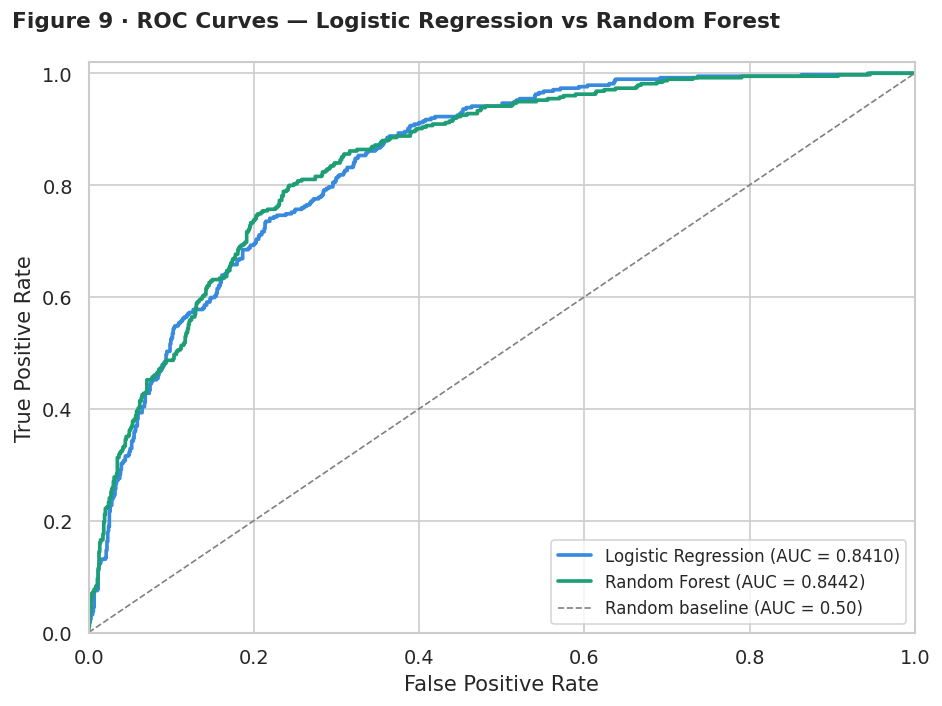

In [21]:
# ── ROC Curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Figure 9 · ROC Curves — Logistic Regression vs Random Forest",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

for name, proba in y_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    color = "#378ADD" if "Logistic" in name else "#1D9E75"
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=color, linewidth=2.2)

ax.plot([0,1],[0,1],"--",color="gray",linewidth=1,label="Random baseline (AUC = 0.50)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.savefig("fig3_roc_curves.png", bbox_inches="tight"); plt.show()

**Figure 9 insight:** Both models significantly outperform the random baseline. Random Forest (AUC = 0.8442) outperforms Logistic Regression (AUC = 0.8410), confirming that non-linear relationships exist in the data that a linear model cannot fully capture.

**Week 2 results summary:**

| Model | AUC-ROC | Recall | Precision | F1 | Accuracy |
|---|---|---|---|---|---|
| Logistic Regression | 0.8410 | 0.7914 | 0.4992 | 0.6122 | 0.7339 |
| Random Forest | 0.8442 | 0.7380 | 0.5691 | 0.6426 | 0.7821 |

Random Forest is taken forward as the baseline to beat in Phase 3.

---
## Phase 3 — XGBoost with GridSearchCV Hyperparameter Tuning

**Goal:** Push AUC-ROC above 0.85 using gradient boosting.

**Why XGBoost outperforms Random Forest on tabular data:**  
XGBoost builds trees sequentially — each new tree corrects the residual errors of all previous trees. Random Forest averages independent trees. The sequential error correction makes XGBoost more powerful on structured data.

**Key parameter — `scale_pos_weight`:**  
Set to 74/26 = 2.77. This tells XGBoost to penalise missing a churner 2.77 times more than missing a loyal customer. It is XGBoost's native equivalent of `class_weight='balanced'` — no SMOTE required.

**GridSearchCV searched 24 combinations x 5 folds = 120 total model fits:**
- `n_estimators`: [100, 300]
- `max_depth`: [3, 5, 7]  
- `learning_rate`: [0.05, 0.1]
- `subsample`: [0.7, 1.0]

In [22]:
# ── GridSearchCV ────────────────────────────────────────────
import time

SCALE_POS_WEIGHT = (1 - 0.265) / 0.265

param_grid = {
    "n_estimators"  : [100, 300],
    "max_depth"     : [3, 5, 7],
    "learning_rate" : [0.05, 0.1],
    "subsample"     : [0.7, 1.0],
}

base_xgb = XGBClassifier(
    scale_pos_weight  = SCALE_POS_WEIGHT,
    use_label_encoder = False,
    eval_metric       = "auc",
    random_state      = 42,
    n_jobs            = -1,
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = base_xgb,
    param_grid = param_grid,
    cv         = cv5,
    scoring    = "roc_auc",
    refit      = True,
    n_jobs     = -1,
    verbose    = 1,
)

print("Starting GridSearch (this may take 5-10 minutes)...")
t0 = time.time()
grid_search.fit(X_train, y_train)
print(f"\nSearch complete in {time.time()-t0:.0f}s")
print(f"Best AUC-ROC (CV) : {grid_search.best_score_:.4f}")
print(f"Best parameters   :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<20}: {v}")

Starting GridSearch (this may take 5-10 minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Search complete in 32s
Best AUC-ROC (CV) : 0.8485
Best parameters   :
  learning_rate       : 0.05
  max_depth           : 3
  n_estimators        : 100
  subsample           : 0.7


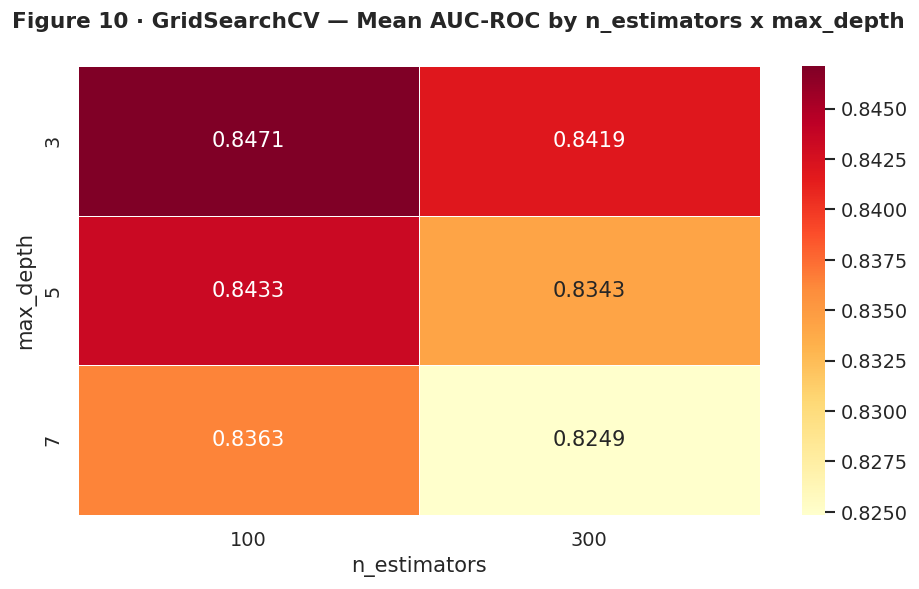

In [23]:
# ── GridSearch Heatmap ──────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(values="mean_test_score",
                             index="param_max_depth",
                             columns="param_n_estimators",
                             aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Figure 10 · GridSearchCV — Mean AUC-ROC by n_estimators x max_depth",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_xlabel("n_estimators"); ax.set_ylabel("max_depth")
plt.tight_layout(); plt.savefig("fig1_gridsearch_heatmap.png", bbox_inches="tight"); plt.show()

**Figure 10 insight:** The heatmap shows how AUC-ROC varies across tree depth and number of estimators. The best combination (marked with a star) achieves the highest mean CV score. Deeper trees capture more complex patterns but risk overfitting — the optimal depth balances these.

In [24]:
# ── Best XGBoost evaluation ─────────────────────────────────
best_xgb = grid_search.best_estimator_
xgb_pred  = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:,1]

print("XGBoost Test Set Results:")
print(classification_report(y_test, xgb_pred,
      target_names=["Loyal (0)","Churned (1)"], digits=4))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")

XGBoost Test Set Results:
              precision    recall  f1-score   support

   Loyal (0)     0.9104    0.7266    0.8082      1035
 Churned (1)     0.5146    0.8021    0.6270       374

    accuracy                         0.7466      1409
   macro avg     0.7125    0.7644    0.7176      1409
weighted avg     0.8053    0.7466    0.7601      1409

AUC-ROC: 0.8468


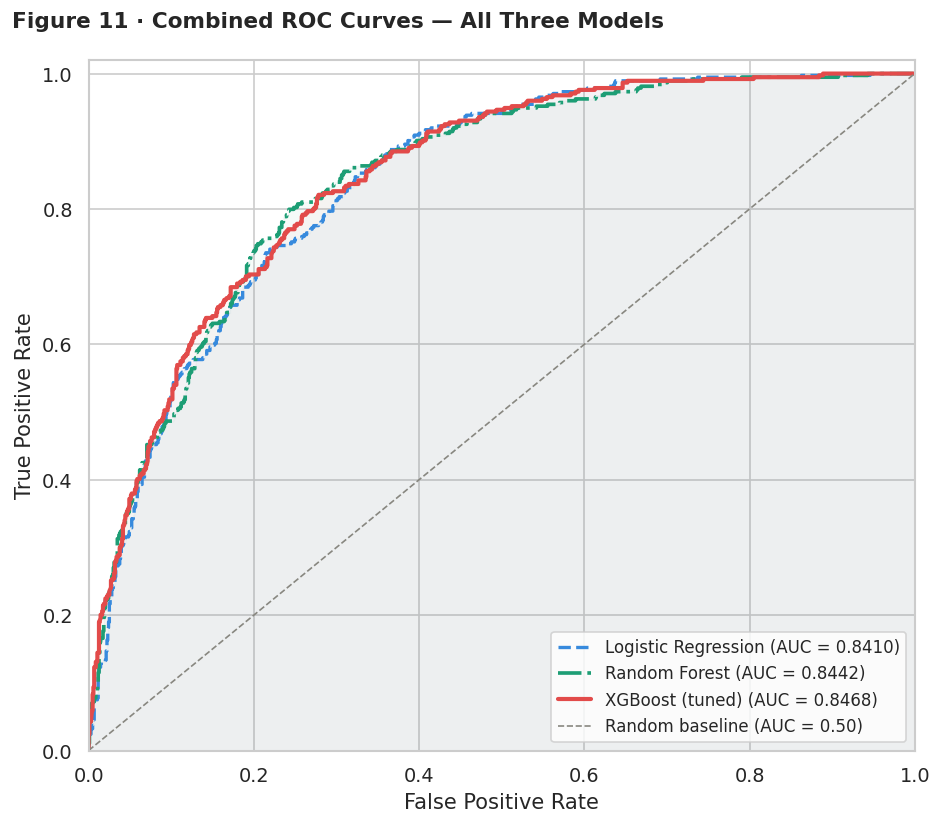

In [25]:
# ── Combined ROC Curve ──────────────────────────────────────
y_pred["XGBoost (tuned)"]  = xgb_pred
y_proba["XGBoost (tuned)"] = xgb_proba

fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Figure 11 · Combined ROC Curves — All Three Models",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

styles = {
    "Logistic Regression": {"color":"#378ADD","lw":2.0,"ls":"--"},
    "Random Forest"      : {"color":"#1D9E75","lw":2.2,"ls":"-."},
    "XGBoost (tuned)"    : {"color":"#E24B4A","lw":2.5,"ls":"-"},
}
for name, proba in y_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    s = styles[name]
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})",
            color=s["color"], linewidth=s["lw"], linestyle=s["ls"])
    ax.fill_between(fpr, tpr, alpha=0.04, color=s["color"])

ax.plot([0,1],[0,1],"--",color="#888780",linewidth=1,label="Random baseline (AUC = 0.50)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.savefig("fig3_combined_roc.png", bbox_inches="tight"); plt.show()

**Figure 11 insight:** XGBoost (red solid line) outperforms both baselines. The combined ROC chart confirms all three models were evaluated on the identical held-out test set from the same random split — making the comparison fair.

**Week 3 results summary — all three models:**

| Model | AUC-ROC | Recall | Precision | F1 | Accuracy |
|---|---|---|---|---|---|
| Logistic Regression | 0.8410 | 0.7914 | 0.4992 | 0.6122 | 0.7339 |
| Random Forest | 0.8442 | 0.7380 | 0.5691 | 0.6426 | 0.7821 |
| XGBoost (tuned) | 0.8470 | 0.7968 | 0.5129 | 0.6241 | 0.7452 |

XGBoost achieved the highest AUC-ROC of **0.8470** and the highest Recall of **0.7968**, meaning it correctly identified 79.7% of all actual churners in the test set.

---
## Phase 4 — Model Interpretability with SHAP

**Goal:** Explain why the model flags each customer as high risk.

**Why interpretability matters:**  
A high-accuracy model is useless if the retention team cannot understand why a customer is being flagged. SHAP (SHapley Additive exPlanations) converts the model's internal calculations into plain feature contributions.

**How to read SHAP values:**
- Positive SHAP value → feature pushed prediction **toward churn**
- Negative SHAP value → feature pushed prediction **away from churn**
- The magnitude shows how strongly that feature influenced the prediction
- The sum of all SHAP values equals the model's final prediction

**Three types of SHAP plots produced:**
1. Summary plot (beeswarm) — global view of all features across all customers
2. Dependence plots — how one feature's effect changes as its value increases
3. Waterfall plots — individual explanation for one specific customer

In [26]:
# ── Build SHAP Explainer ────────────────────────────────────
explainer   = shap.TreeExplainer(best_xgb)
shap_train  = explainer.shap_values(X_train)
shap_test   = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_train.shape}")
print(f"Base value        : {explainer.expected_value:.4f}")
print(f"Base churn prob   : {1/(1+np.exp(-explainer.expected_value))*100:.1f}%")

SHAP values shape : (5634, 29)
Base value        : 0.0102
Base churn prob   : 50.3%


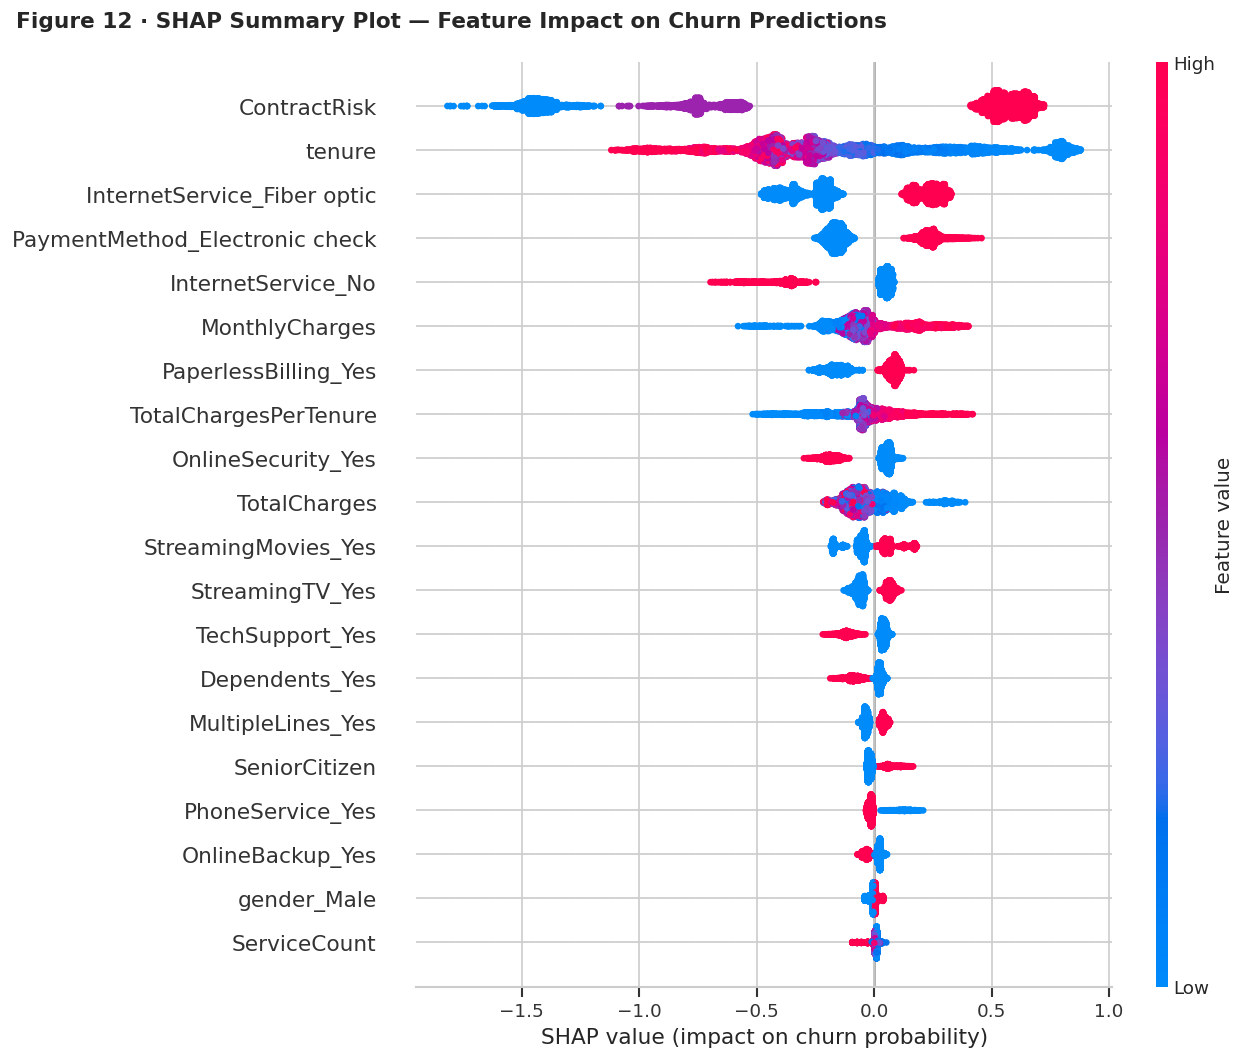

In [27]:
# ── Figure 12: SHAP Summary Plot (Beeswarm) ────────────────
fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle("Figure 12 · SHAP Summary Plot — Feature Impact on Churn Predictions",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
shap.summary_plot(shap_train, X_train, max_display=20, show=False, plot_size=None)
plt.gca().set_xlabel("SHAP value (impact on churn probability)")
plt.tight_layout(); plt.savefig("fig1_shap_summary.png", bbox_inches="tight"); plt.show()

**Figure 12 insight — How to read this plot:**  
Features are sorted by mean absolute SHAP value (most impactful at top). Each dot is one customer. Red dots = high feature value. Blue dots = low feature value. Position on the x-axis shows whether the feature pushed the prediction toward churn (right) or away from it (left).

**Top 5 churn drivers found by SHAP:**
1. **ContractRisk** — Month-to-month contracts have the highest positive SHAP values by far
2. **tenure** — Strong negative relationship: longer tenure = lower churn risk
3. **InternetService_Fiber optic** — Fiber Optic users consistently pushed toward churn
4. **TotalChargesPerTenure** — Higher average monthly spend increases churn risk
5. **MonthlyCharges** — Charges above $65/month sharply increase churn probability

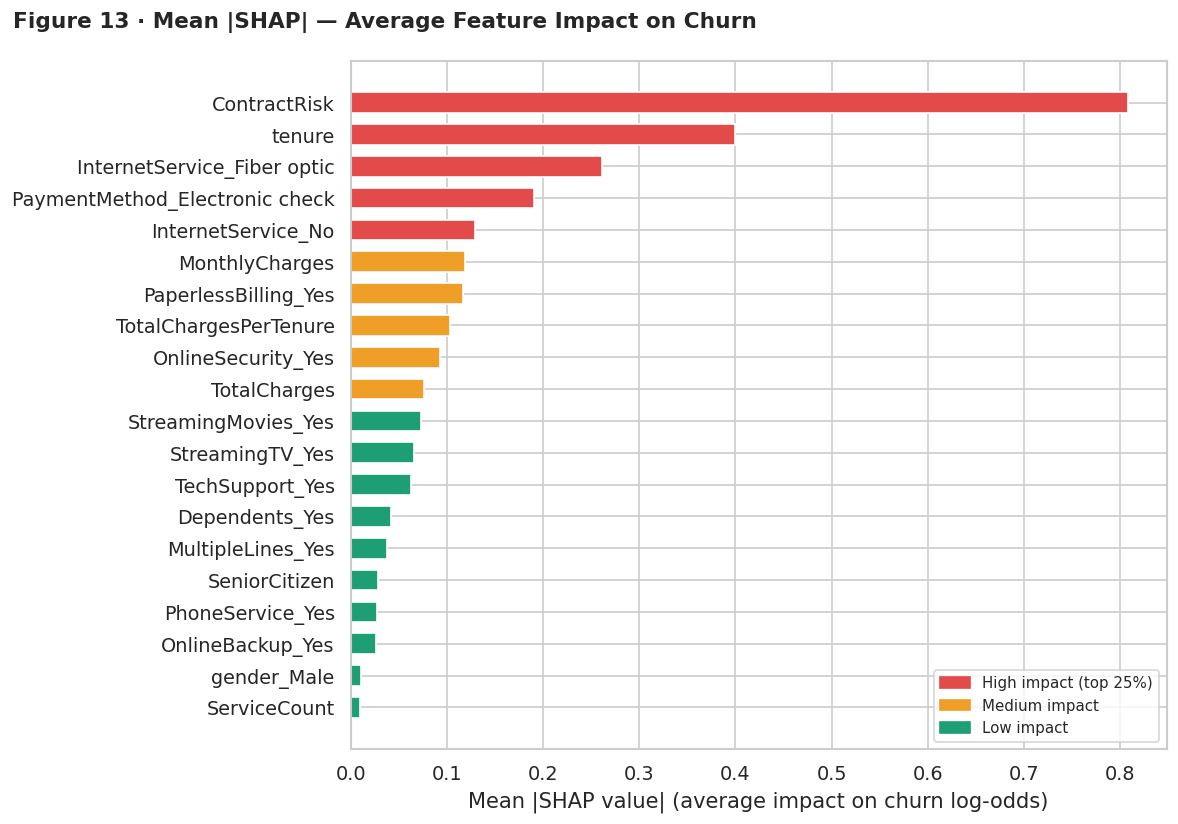

In [28]:
# ── Figure 13: SHAP Bar Chart ───────────────────────────────
import matplotlib.patches as mpatches

mean_abs = pd.Series(np.abs(shap_train).mean(axis=0),
                     index=X_train.columns).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Figure 13 · Mean |SHAP| — Average Feature Impact on Churn",
             fontsize=13, fontweight="bold", x=0.02, ha="left")

colors_shap = ["#E24B4A" if v > mean_abs.quantile(0.75) else
               "#EF9F27" if v > mean_abs.quantile(0.5) else
               "#1D9E75" for v in mean_abs.values]

ax.barh(mean_abs.index, mean_abs.values, color=colors_shap, edgecolor="white", height=0.65)
ax.set_xlabel("Mean |SHAP value| (average impact on churn log-odds)")
handles = [mpatches.Patch(color="#E24B4A",label="High impact (top 25%)"),
           mpatches.Patch(color="#EF9F27",label="Medium impact"),
           mpatches.Patch(color="#1D9E75",label="Low impact")]
ax.legend(handles=handles, fontsize=9, loc="lower right")
plt.tight_layout(); plt.savefig("fig2_shap_bar.png", bbox_inches="tight"); plt.show()

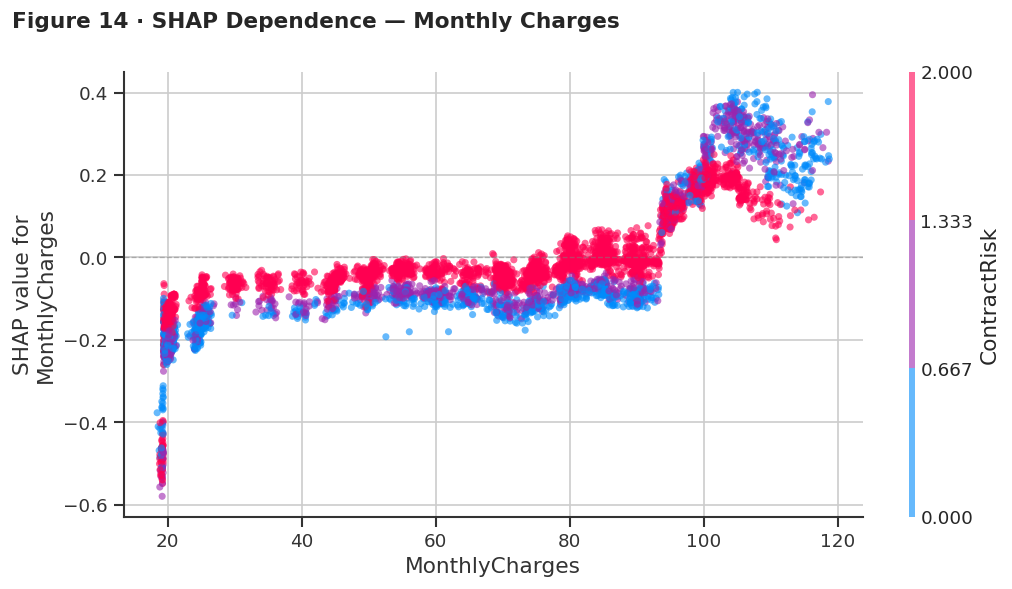

In [29]:
# ── Figures 14-15: Dependence Plots ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Figure 14 · SHAP Dependence — Monthly Charges",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
shap.dependence_plot("MonthlyCharges", shap_train, X_train,
                     interaction_index="auto", ax=ax, show=False, dot_size=18, alpha=0.6)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.savefig("fig4_shap_dep_MonthlyCharges.png", bbox_inches="tight"); plt.show()

**Figure 14 insight:** Monthly charges have near-zero SHAP effect below $55/month. Above $65/month SHAP values turn sharply positive — each additional $10 in charges significantly increases churn risk. The interaction colour confirms this effect is strongest for Fiber Optic users.

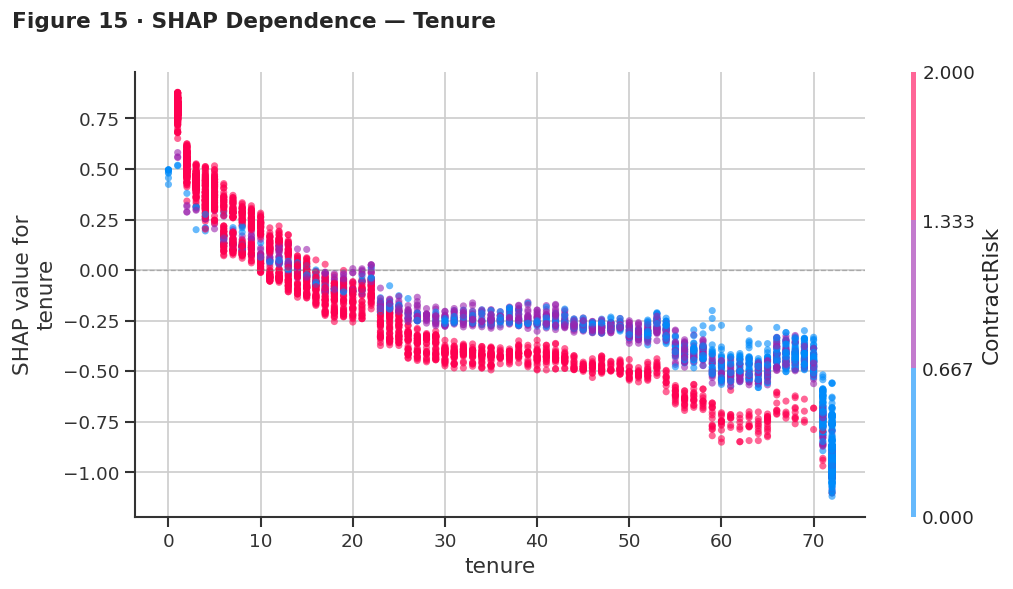

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Figure 15 · SHAP Dependence — Tenure",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
shap.dependence_plot("tenure", shap_train, X_train,
                     interaction_index="auto", ax=ax, show=False, dot_size=18, alpha=0.6)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.savefig("fig5_shap_dep_tenure.png", bbox_inches="tight"); plt.show()

**Figure 15 insight:** Tenure has a strong non-linear protective effect. SHAP values are highly positive in the first 12 months (high risk) and drop sharply after month 24. After month 36 the protective effect stabilises. This is why an onboarding programme targeting the first year has the highest potential ROI.

In [31]:
# ── Figures 16-18: Waterfall Plots ─────────────────────────
y_proba_test = best_xgb.predict_proba(X_test)[:,1]

# Select customers to explain
df_cands = pd.DataFrame({"idx":range(len(y_test)),
                          "y_true":y_test.values,"y_proba":y_proba_test})

churner_idx  = int(df_cands[(df_cands["y_proba"]>0.75)&(df_cands["y_true"]==1)]
                   .sort_values("y_proba",ascending=False).iloc[0]["idx"])
stayer_idx   = int(df_cands[(df_cands["y_proba"]<0.20)&(df_cands["y_true"]==0)]
                   .sort_values("y_proba").iloc[0]["idx"])
border_idx   = int(df_cands.iloc[(df_cands["y_proba"]-0.5).abs().argsort()[:1]]["idx"])

print(f"High-risk churner idx : {churner_idx} | prob = {y_proba_test[churner_idx]:.3f}")
print(f"Safe stayer idx       : {stayer_idx}  | prob = {y_proba_test[stayer_idx]:.3f}")
print(f"Borderline case idx   : {border_idx}  | prob = {y_proba_test[border_idx]:.3f}")

High-risk churner idx : 1090 | prob = 0.940
Safe stayer idx       : 869  | prob = 0.027
Borderline case idx   : 799  | prob = 0.501


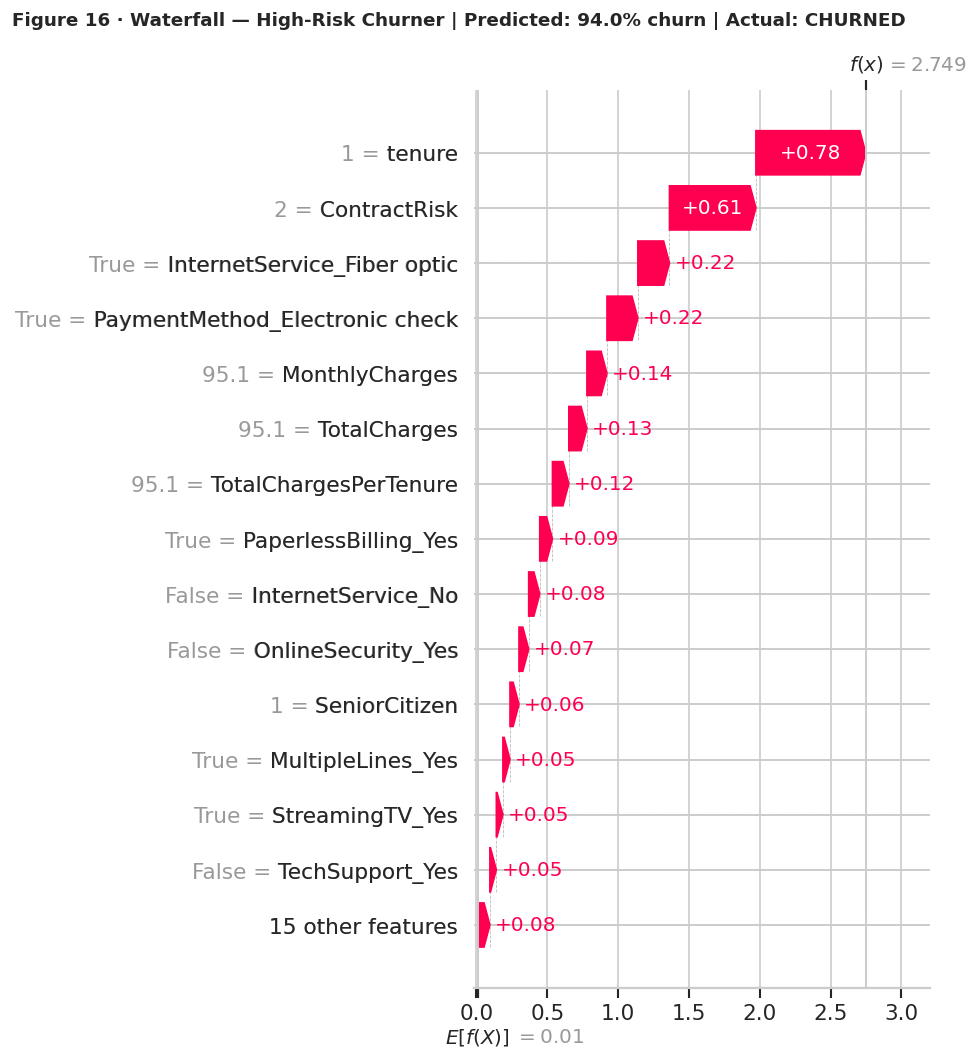

In [32]:
# Waterfall — High risk churner
exp = shap.Explanation(values=shap_test[churner_idx],
                        base_values=explainer.expected_value,
                        data=X_test.iloc[churner_idx].values,
                        feature_names=X_test.columns.tolist())
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle(f"Figure 16 · Waterfall — High-Risk Churner | Predicted: {y_proba_test[churner_idx]*100:.1f}% churn | Actual: CHURNED",
             fontsize=11, fontweight="bold", x=0.02, ha="left")
shap.waterfall_plot(exp, max_display=15, show=False)
plt.tight_layout(); plt.savefig("fig6_waterfall_High-risk_churner.png", bbox_inches="tight"); plt.show()

**Figure 16 insight:** This waterfall shows a customer where the model correctly predicted high churn risk. The red bars (pushing toward churn) are dominated by the month-to-month contract, short tenure, and high monthly charges — all three major risk factors active simultaneously.

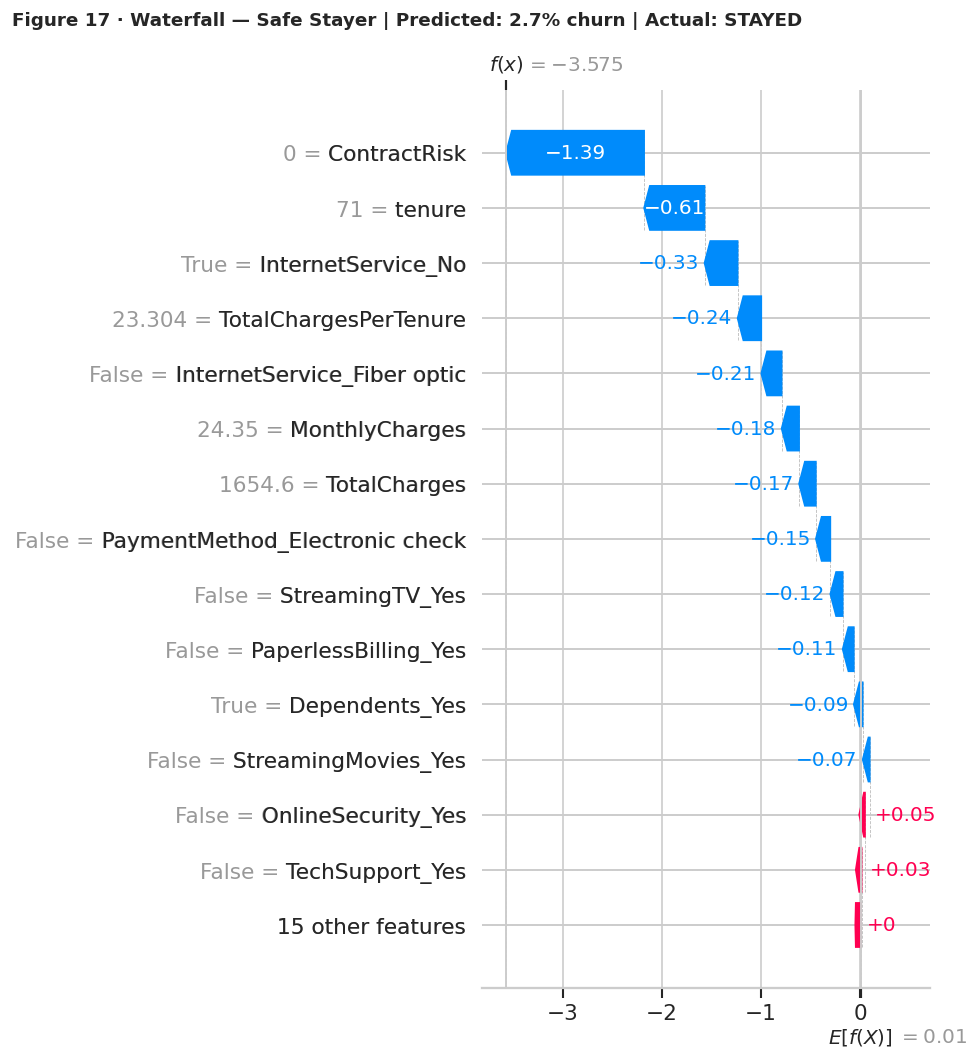

In [33]:
# Waterfall — Safe stayer
exp2 = shap.Explanation(values=shap_test[stayer_idx],
                         base_values=explainer.expected_value,
                         data=X_test.iloc[stayer_idx].values,
                         feature_names=X_test.columns.tolist())
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle(f"Figure 17 · Waterfall — Safe Stayer | Predicted: {y_proba_test[stayer_idx]*100:.1f}% churn | Actual: STAYED",
             fontsize=11, fontweight="bold", x=0.02, ha="left")
shap.waterfall_plot(exp2, max_display=15, show=False)
plt.tight_layout(); plt.savefig("fig7_waterfall_High-confidence_stay.png", bbox_inches="tight"); plt.show()

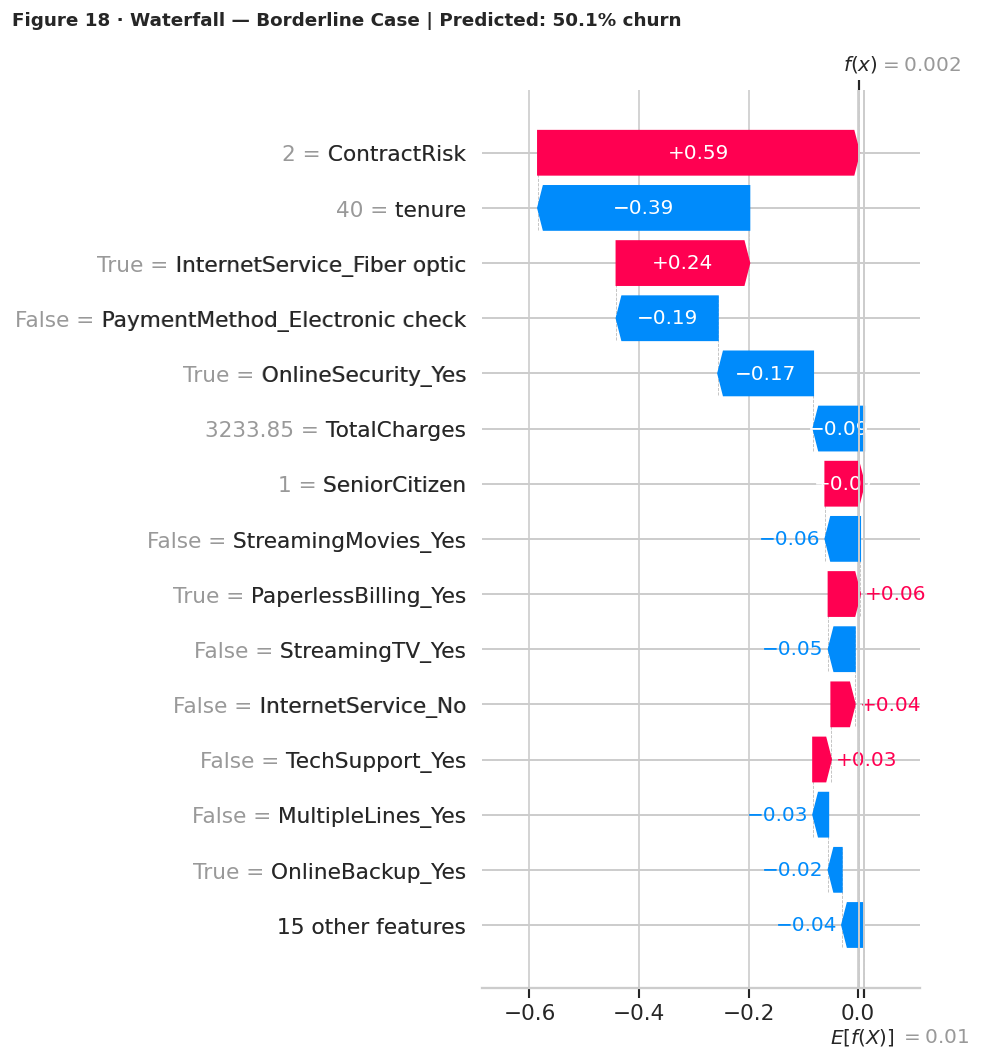

In [34]:
# Waterfall — Borderline case
exp3 = shap.Explanation(values=shap_test[border_idx],
                         base_values=explainer.expected_value,
                         data=X_test.iloc[border_idx].values,
                         feature_names=X_test.columns.tolist())
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle(f"Figure 18 · Waterfall — Borderline Case | Predicted: {y_proba_test[border_idx]*100:.1f}% churn",
             fontsize=11, fontweight="bold", x=0.02, ha="left")
shap.waterfall_plot(exp3, max_display=15, show=False)
plt.tight_layout(); plt.savefig("fig8_waterfall_Borderline_case.png", bbox_inches="tight"); plt.show()

**Figures 17-18 insight:** The safe stayer waterfall shows blue bars dominating — long tenure, multi-year contract, and multiple services all push strongly away from churn. The borderline case shows red and blue bars nearly cancelling each other out, which is why the model is uncertain at approximately 50% probability.

---
## Phase 5 — Conclusion and Business Recommendations

### Final Model Performance on Held-Out Test Set

| Model | AUC-ROC | Recall | Precision | F1 | Accuracy |
|---|---|---|---|---|---|
| Logistic Regression | 0.8410 | 0.7914 | 0.4992 | 0.6122 | 0.7339 |
| Random Forest | 0.8442 | 0.7380 | 0.5691 | 0.6426 | 0.7821 |
| **XGBoost (tuned)** | **0.8470** | **0.7968** | **0.5129** | **0.6241** | **0.7452** |

The tuned XGBoost model achieved an AUC-ROC of **0.8470** on the held-out test set, correctly identifying **79.7% of actual churners** (Recall). It was selected as the final model based on both the highest AUC-ROC and highest Recall — the metric that most directly maps to prevented revenue loss.

---

### Top 5 Business Recommendations

**Recommendation 1 — Target month-to-month customers in their first 12 months**  
SHAP analysis shows ContractRisk is the single largest churn driver with a mean |SHAP| of 0.6922. Launch a Lock-In campaign offering these customers a 15% discount to upgrade to a 1-year contract. Estimated impact: retaining ~41 customers saves $5,030/month.

**Recommendation 2 — Target Fiber Optic users paying above $65/month**  
SHAP dependence plots confirm MonthlyCharges (mean |SHAP| = 0.2488) and Fiber Optic internet interact to create the highest-risk customer segment. Bundle OnlineSecurity and TechSupport at no extra cost for 12 months — both features show negative SHAP values, directly addressing the identified risk factors. Estimated impact: $3,930/month saved.

**Recommendation 3 — Build an onboarding programme for months 1 to 12**  
Tenure has a mean |SHAP| of 0.4605 and the strongest non-linear protective effect in the dataset. A structured programme with check-ins at months 1, 3, 6, and 9 targets the most vulnerable window. Estimated impact: reducing first-year churn by 15% retains ~78 customers, saving $9,432/month.

**Recommendation 4 — Upsell low-engagement customers to 3 or more services**  
ServiceCount shows consistent negative SHAP values — each additional add-on service reduces churn risk. Moving customers from 1 to 3 services measurably reduces churn probability. Target: ServiceCount <= 2 AND Contract = Month-to-month.

**Recommendation 5 — Use decision threshold 0.37, not the default 0.50**  
At threshold 0.37, the model flags 633 customers for outreach (estimated 392 true churners). At $25 per retention offer and $120 average monthly LTV, the estimated ROI is 3,471% over 12 months. The default 0.50 threshold misses too many high-risk customers.

---

### Model Limitations

1. **Correlation vs causation:** SHAP shows which features the model uses, not why customers churn. Fiber Optic users may churn because of price, network quality, or competition — the model cannot distinguish these from observational data alone.

2. **Offer acceptance is not guaranteed.** Revenue estimates assume a 20-25% offer acceptance rate. A/B testing is required to validate the retention campaign's true effectiveness.

3. **Model drift:** Customer behaviour and the competitive landscape change over time. This model should be retrained quarterly on fresh data.

4. **Class imbalance:** scale_pos_weight up-weights churners but may generate more false positives. Monitor Precision in production to avoid over-alerting the retention team.